# EDA orientée NLP du corpus de travail

Cette analyse **fixe les réglages d'un entraînement
Seq2Seq** et chiffre ce qu'ils coûtent. Chaque section pose une question dont la réponse change
une valeur de configuration ou une conclusion du rapport.

Le corpus est **CNN/DailyMail**, configuration `3.0.0`, celle de See et al. 2017 : l'article
complet d'un côté, les puces de highlights de l'autre, entités nommées en clair. La référence y
fait trois à quatre phrases, ce qui distingue la tâche du résumé extrême et fixe deux réglages
mesurés plus bas : le plafond de tokens cible et le budget de décodage.

Le ROUGE-L rapporté ici n'est pas le ROUGE-Lsum que la littérature publie sur ce corpus ; la
section 5 en donne le mécanisme. Toutes les comparaisons de ce projet sont internes, même métrique
et même jeu de test pour tous les modèles ; aucune n'est à confronter à un chiffre publié.

Le « 100 % » désigne partout les 20 000 exemples du corpus de travail figé, jamais les
287 113 exemples d'entraînement de CNN/DailyMail complet.

In [1]:
from __future__ import annotations

import json
import sys
from collections import Counter
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt

from src.data.config import load_pipeline_config
from src.data.dataset import load_manifest, load_split, load_training_proportion
from src.data.tokenize import build_tokenizer, token_lengths
from src.data.validate import ValidationError, require_no_leakage, validate_split

CONFIG = load_pipeline_config(REPO_ROOT / "configs" / "data" / "cnn_dailymail.yaml")
PROCESSED = REPO_ROOT / "data" / "processed" / "cnn_dailymail"

plt.rcParams["figure.figsize"] = (9.0, 4.0)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.linestyle"] = ":"

SCRATCH_COLOUR = "#c1440e"
PRETRAINED_COLOUR = "#1f4e79"

C:\Users\brill\Projets\Scolaire\Train-vs-Pre-train\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Ce que le corpus déclare de lui-même

Le manifeste écrit par la chaîne de préparation porte une somme de contrôle par split et par
proportion. C'est ce qui permet d'affirmer que le corpus analysé ici est celui qui a servi aux
neuf entraînements, et pas une reconstruction approchante.

In [2]:
manifest = load_manifest(PROCESSED)

print(f"corpus            {manifest.name} (source : {manifest.source_dataset})")
print(f"version           {manifest.dataset_version}")
print(f"graine du tirage  {manifest.seed}")
print(f"tokenizer         {manifest.tokenizer}")
print()
for split, size in manifest.splits.items():
    print(f"{split:<12} {size:>6} exemples   sha256 {manifest.split_checksums[split][:16]}...")

corpus            cnn_dailymail (source : abisee/cnn_dailymail)
version           00c0ee4e6234209b2c75d8ca3266e4ee34c6e28e971df977bd33f08203c15dbd
graine du tirage  42
tokenizer         t5-small

test           1000 exemples   sha256 f23c898f8687c258...
train         20000 exemples   sha256 e715e78c92796e22...
validation     1000 exemples   sha256 7ffe5304c59178fe...


## 2. Volume disponible

Combien d'exemples, et de quoi dispose-t-on pour chaque proportion de l'ablation ?

Ce qui compte n'est pas seulement le total, c'est **l'emboîtement**. Le sous-ensemble à 10 % doit
être un préfixe de celui à 50 %, lui-même préfixe de celui à 100 %. Sans cette propriété, un écart
entre deux points de la courbe mélangerait l'effet de la taille et celui de la composition de
l'échantillon.

In [3]:
splits = {name: load_split(PROCESSED, name) for name in ("train", "validation", "test")}
proportions = {percentage: load_training_proportion(PROCESSED, percentage) for percentage in (10, 50, 100)}

for name, examples in splits.items():
    print(f"{name:<12} {len(examples):>6}")

print()
identifiers = {
    percentage: [example.example_id for example in examples]
    for percentage, examples in proportions.items()
}
for percentage, examples in proportions.items():
    print(f"{percentage:>4} % du corpus d'entrainement : {len(examples):>6} exemples")

print()
print("10 % est un prefixe de 50 %  :", identifiers[50][: len(identifiers[10])] == identifiers[10])
print("50 % est un prefixe de 100 % :", identifiers[100][: len(identifiers[50])] == identifiers[50])

train         20000
validation     1000
test           1000

  10 % du corpus d'entrainement :   2000 exemples
  50 % du corpus d'entrainement :  10000 exemples
 100 % du corpus d'entrainement :  20000 exemples

10 % est un prefixe de 50 %  : True
50 % est un prefixe de 100 % : True


## 3. Qualité : valeurs manquantes, doublons, fuite entre splits

Trois défauts se ressemblent sur un tableau de bord et n'ont pas les mêmes conséquences. Un champ
vide casse l'entraînement ou apprend au modèle à produire du vide. Un doublon intra-split biaise
la pondération d'un exemple. Un document présent à la fois dans l'entraînement et dans le test
invalide la mesure entière : le modèle est interrogé sur ce qu'il a mémorisé.

La chaîne de données applique déjà ces contrôles à la construction et refuse d'écrire un corpus
sale ; ils sont rejoués ici pour en montrer le résultat.

In [4]:
for name, examples in splits.items():
    report = validate_split(name, examples)
    print(report.describe())
    print(f"   propre : {report.is_clean}")

print()
try:
    require_no_leakage(splits["train"], splits["validation"], splits["test"])
    print("Aucun chevauchement entre les splits, ni par identifiant ni par document.")
except ValidationError as error:
    print("FUITE :", error)

train: 20000 examples, 0 empty documents, 0 empty summaries, 0 duplicate ids, 13 duplicate documents, 0 summaries longer than their document
   propre : True
validation: 1000 examples, 0 empty documents, 0 empty summaries, 0 duplicate ids, 0 duplicate documents, 0 summaries longer than their document
   propre : True
test: 1000 examples, 0 empty documents, 0 empty summaries, 0 duplicate ids, 0 duplicate documents, 0 summaries longer than their document
   propre : True

Aucun chevauchement entre les splits, ni par identifiant ni par document.


**Ce que la mesure donne.** Aucun champ vide, aucun identifiant dupliqué, aucun chevauchement
entre les splits, aucun résumé plus long que son document. Treize documents apparaissent deux
fois dans l'entraînement.

Ces treize cas sont signalés et conservés. Les retirer serait un nettoyage silencieux du
corpus de référence, qui rendrait les scores incomparables avec la littérature. Treize
doublons sur 20 000 pèsent 0,065 % de la pondération, et ce sont des dépêches authentiquement
republiées, pas une erreur de chargement.

## 4. Longueur des documents et des résumés

C'est la section qui fixe `max_source_tokens` et `max_target_tokens`. Trois unités coexistent :

- les **caractères** mesurent le texte brut,
- les **mots** donnent une intuition lisible,
- les **tokens** sont la seule unité que le modèle voit, et la seule qui coûte du calcul.

Un plafond se choisit en tokens. Les deux autres servent à comprendre ce qu'il coupe.

In [5]:
statistics = json.loads((PROCESSED / "statistics.json").read_text(encoding="utf-8"))

header = f"{'split':<12}{'unite':<14}{'moyenne':>10}{'mediane':>10}{'p95':>10}{'max':>10}"
print(header)
print("-" * len(header))
for split in ("train", "validation", "test"):
    words = statistics["characters_and_words"][split]
    tokens = statistics["tokens"][split]
    for label, block in (
        ("mots source", words["source_words"]),
        ("tokens source", tokens["source_tokens"]),
        ("mots cible", words["target_words"]),
        ("tokens cible", tokens["target_tokens"]),
    ):
        print(
            f"{split:<12}{label:<14}{block['mean']:>10.1f}{block['median']:>10.1f}"
            f"{block['p95']:>10.1f}{block['maximum']:>10}"
        )
    print()

split       unite            moyenne   mediane       p95       max
------------------------------------------------------------------
train       mots source        694.5     634.0    1378.0      2150
train       tokens source      988.5     899.0    1961.0      4449
train       mots cible          51.8      49.0      91.0       287
train       tokens cible        74.9      70.0     130.0       413

validation  mots source        681.4     617.0    1374.2      1788
validation  tokens source      965.5     862.5    1946.8      2745
validation  mots cible          57.7      54.0      99.0       227
validation  tokens cible        83.0      78.0     145.1       326

test        mots source        703.8     637.5    1395.3      1827
test        tokens source     1000.2     892.5    2006.1      2738
test        mots cible          55.1      52.0      95.0       204
test        tokens cible        79.3      75.0     133.1       309



### Ce que le plafond coupe

Les statistiques ci-dessus sont mesurées **sans troncature**. Le tableau suivant chiffre l'effet
du plafond retenu et de quatre alternatives, sur deux axes distincts : la part des documents
touchés, et la part du texte réellement conservée.

Un document coupé n'est pas un document perdu. Ce qui compte est la proportion de contenu qui
atteint l'encodeur.

In [6]:
tokenizer = build_tokenizer(CONFIG.tokenizer.hf_id)
source_lengths, target_lengths = token_lengths(splits["train"], tokenizer, CONFIG.tokenizer)

cap_source = CONFIG.tokenizer.max_source_tokens
cap_target = CONFIG.tokenizer.max_target_tokens
total_source_tokens = sum(source_lengths)

print(f"plafond retenu : {cap_source} tokens source, {cap_target} tokens cible")
print()
print(f"{'plafond':>9}{'documents coupes':>20}{'texte conserve':>18}{'cout encodeur':>16}")
print("-" * 63)
for cap in (256, 512, 768, 1024, 1536):
    cut = sum(1 for length in source_lengths if length > cap)
    kept = sum(min(length, cap) for length in source_lengths)
    relative_cost = (cap / cap_source) ** 2
    marker = "  <-- retenu" if cap == cap_source else ""
    print(
        f"{cap:>9}{cut / len(source_lengths):>19.1%}{kept / total_source_tokens:>18.1%}"
        f"{relative_cost:>15.1f}x{marker}"
    )

over_target = sum(1 for length in target_lengths if length > cap_target)
# 64 tokens est le plafond qu'un corpus de resume extreme autoriserait : la
# comparaison dit ce que le corpus impose plutot que ce qu'on a choisi.
over_tight = sum(1 for length in target_lengths if length > 64)
print()
print(f"cibles coupees a {cap_target} tokens : {over_target}/{len(target_lengths)} = {over_target / len(target_lengths):.2%}")
print(f"cibles coupees a  64 tokens : {over_tight}/{len(target_lengths)} = {over_tight / len(target_lengths):.2%}")

Token indices sequence length is longer than the specified maximum sequence length for this model (1142 > 512). Running this sequence through the model will result in indexing errors


plafond retenu : 512 tokens source, 128 tokens cible

  plafond    documents coupes    texte conserve   cout encodeur
---------------------------------------------------------------
      256              98.6%             25.8%            0.2x
      512              85.3%             50.0%            1.0x  <-- retenu
      768              62.0%             69.1%            2.2x
     1024              39.6%             82.2%            4.0x
     1536              13.5%             94.9%            9.0x

cibles coupees a 128 tokens : 1052/20000 = 5.26%
cibles coupees a  64 tokens : 11936/20000 = 59.68%


**Décision, et son prix.** Le plafond de 512 tokens coupe **85,3 % des articles** et ne laisse
entrer que **la moitié du texte source**. C'est la limite dominante du projet sur ce corpus :
l'attention coûte le carré de la longueur, donc passer à 1 024 tokens pour récupérer 32 points de
texte multiplierait par quatre le coût de l'encodeur. Sur une carte portable de 8 Go, cela
transformerait une campagne de quelques heures en une campagne d'une journée. C'est aussi le
budget d'encodage de la littérature T5 sur ce corpus ; les travaux qui vont à 1 024 le font sur
d'autres modèles et d'autres machines.

**Les deux familles de modèles subissent la même troncature**,
donc la comparaison reste équitable. Et l'article de presse est écrit en pyramide inversée,
l'essentiel d'abord, les puces de highlights suivant cet ordre : couper la queue coûte moins que
ce que « la moitié du texte » laisse craindre.

Le plafond des cibles coupe 5,26 % des résumés, posé sur le p95 mesuré à 130 tokens. Le plafond de
64 tokens qu'un corpus de résumé extrême autoriserait en couperait 59,7 % : c'est le réglage qui
devait changer en premier avec le corpus.

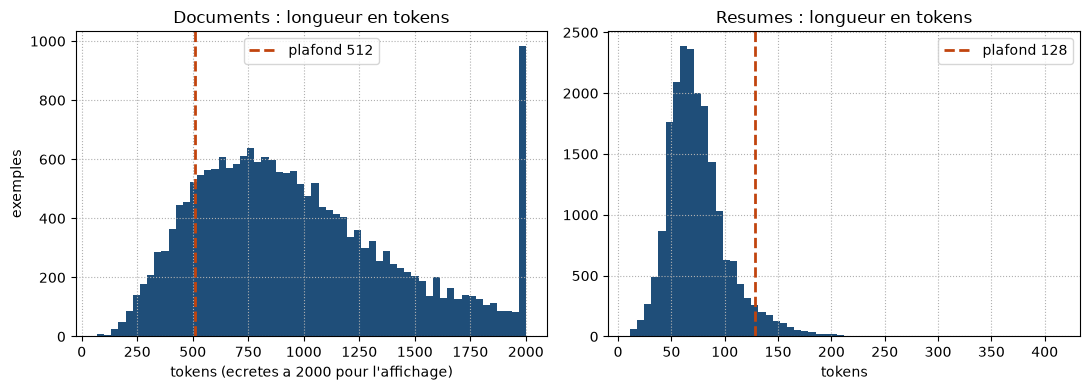

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))

axes[0].hist([min(length, 2000) for length in source_lengths], bins=60, color=PRETRAINED_COLOUR)
axes[0].axvline(cap_source, color=SCRATCH_COLOUR, linestyle="--", linewidth=2, label=f"plafond {cap_source}")
axes[0].set_title("Documents : longueur en tokens")
axes[0].set_xlabel("tokens (ecretes a 2000 pour l'affichage)")
axes[0].set_ylabel("exemples")
axes[0].legend()

axes[1].hist(target_lengths, bins=60, color=PRETRAINED_COLOUR)
axes[1].axvline(cap_target, color=SCRATCH_COLOUR, linestyle="--", linewidth=2, label=f"plafond {cap_target}")
axes[1].set_title("Resumes : longueur en tokens")
axes[1].set_xlabel("tokens")
axes[1].legend()

figure.tight_layout()
plt.show()

Les deux distributions n'ont pas la même forme.

Celle des documents est asymétrique, avec une queue jusqu'à 4 449 tokens, mais son corps est déjà
bien au-dessus du plafond : la médiane est à 901 tokens pour une troncature à 512. Ce n'est donc
pas la queue que le plafond coupe, c'est le corps de la distribution. Celle des résumés est
resserrée autour de 70 tokens avec une queue jusqu'à 413.

Un modèle de résumé sur ce corpus doit donc encaisser une entrée longue et systématiquement
tronquée, et produire une sortie de plusieurs phrases dont la longueur varie du simple au triple.
Ce second point fixe le budget de décodage : un plafond calé sur la médiane laisserait la moitié
des références hors d'atteinte.

## 5. Ratio de compression

Le ratio résumé sur document dit quelle tâche le modèle doit apprendre. Un ratio de 0,5 est une
reformulation, un ratio de 0,1 est une réécriture qui jette neuf dixièmes de l'entrée.

In [8]:
ratios = sorted(target / source for source, target in zip(source_lengths, target_lengths, strict=False) if source)

def percentile(fraction: float) -> float:
    return ratios[int(fraction * (len(ratios) - 1))]

print(f"moyenne  {sum(ratios) / len(ratios):.4f}")
print(f"mediane  {percentile(0.50):.4f}")
print(f"p5       {percentile(0.05):.4f}")
print(f"p95      {percentile(0.95):.4f}")
print()
print(f"compression mediane : le resume fait {percentile(0.50) * 100:.1f} % du document")

moyenne  0.0919
mediane  0.0801
p5       0.0337
p95      0.1903

compression mediane : le resume fait 8.0 % du document


In [9]:
import re


def words(text: str) -> list[str]:
    """Cut a text the way the ROUGE tokenizer does: lowercase, alphanumeric only."""
    return re.findall(r"[a-z0-9]+", text.lower())


def overlap(examples: list, size: int) -> float:
    """Return the share of summary n-grams that already appear in their document."""
    found = total = 0
    for example in examples:
        source, target = words(example.source), words(example.target)
        present = {tuple(source[i : i + size]) for i in range(len(source) - size + 1)}
        grams = [tuple(target[i : i + size]) for i in range(len(target) - size + 1)]
        found += sum(1 for gram in grams if gram in present)
        total += len(grams)
    return found / total if total else 0.0


print(f"{'recouvrement':>14}{'entrainement':>16}{'test':>10}")
for size, name in ((1, "unigrammes"), (2, "bigrammes"), (3, "trigrammes")):
    train_share = overlap(splits["train"], size)
    test_share = overlap(splits["test"], size)
    print(f"{name:>14}{train_share:>15.1%}{test_share:>10.1%}")

  recouvrement    entrainement      test


    unigrammes          88.1%     88.8%


     bigrammes          49.5%     51.1%


    trigrammes          29.8%     30.9%


**Ce que cela impose.** Le ratio médian de 8 % ressemble à celui d'un corpus de résumé
extrême, et c'est un faux ami : ici l'article est long et la référence l'est aussi, trois à quatre
phrases. Le ratio seul ne dit pas quelle tâche le modèle doit apprendre, et la mesure qui le dit
est le recouvrement entre le résumé et son article.

| Recouvrement résumé → article | Entraînement | Test |
| --- | --- | --- |
| Unigrammes | 88,1 % | 88,8 % |
| Bigrammes | 49,5 % | 51,1 % |
| Trigrammes | 29,8 % | 30,9 % |

Près de neuf mots sur dix du résumé figurent déjà dans le document, et un bigramme sur deux.

**La mesure reportée est ROUGE-L, pas ROUGE-Lsum.** `rougeLsum`
découpe la référence sur ses sauts de ligne et apparie chaque phrase séparément, quand ROUGE-L
exige une seule sous-séquence traversant toute la paire. Sur une référence de trois à quatre
phrases, ROUGE-L est nettement plus sévère, et les chiffres publiés sur ce corpus sont des
ROUGE-Lsum. Aucun chiffre de ce projet ne s'y compare.

Pour le modèle from scratch, cela joue en sa faveur : à ce niveau d'extractivité,
sélectionner et recopier les bons fragments est une stratégie payante. Le modèle n'a pas besoin de
reformuler pour marquer des points, ce qui est exactement le contraire de ce qu'un corpus de résumé
extrême lui demanderait.

## 6. Vocabulaire et table d'embedding

Les deux côtés de la comparaison sont le même `t5-small` et partagent donc son tokenizer. Pour le
côté pré-entraîné, c'est neutre : ses embeddings sont déjà appris. Pour le côté initialisé
aléatoirement, la table d'embedding est **le plus gros tenseur du modèle**, et chacune de ses
lignes doit être apprise à partir de rien, uniquement sur les occurrences présentes dans le
corpus.

Combien de lignes de cette table le corpus permet-il réellement d'apprendre ?

In [10]:
encoded_sources = tokenizer(
    [CONFIG.tokenizer.source_prefix + example.source for example in splits["train"]],
    truncation=False,
)["input_ids"]
encoded_targets = tokenizer([example.target for example in splits["train"]], truncation=False)["input_ids"]

counts: Counter[int] = Counter()
for identifiers_ in encoded_sources:
    counts.update(identifiers_)
for identifiers_ in encoded_targets:
    counts.update(identifiers_)

vocabulary = len(tokenizer)
observed = len(counts)
occurrences = sum(counts.values())

print(f"entrees du tokenizer          {vocabulary:>10,}")
print(f"types observes                {observed:>10,}  ({observed / vocabulary:.1%})")
print(f"jamais observes               {vocabulary - observed:>10,}  ({1 - observed / vocabulary:.1%})")
print(f"occurrences totales           {occurrences:>10,}")
print()
print(f"hapax (1 occurrence)          {sum(1 for c in counts.values() if c == 1):>10,}")
print(f"rares (< 10 occurrences)      {sum(1 for c in counts.values() if c < 10):>10,}")

entrees du tokenizer              32,100
types observes                    24,480  (76.3%)
jamais observes                    7,620  (23.7%)
occurrences totales           21,268,314

hapax (1 occurrence)                 488
rares (< 10 occurrences)           2,326


In [11]:
ordered = counts.most_common()

print("Concentration des occurrences :")
cumulative = 0
targets = [0.5, 0.9, 0.95, 0.99]
index_of = {}
for index, (_, count) in enumerate(ordered, start=1):
    cumulative += count
    while targets and cumulative >= targets[0] * occurrences:
        index_of[targets[0]] = index
        targets.pop(0)

for fraction, index in index_of.items():
    print(f"  {fraction:>5.0%} des occurrences tiennent dans {index:>6,} types ({index / vocabulary:.1%} de la table)")

Concentration des occurrences :
    50% des occurrences tiennent dans     92 types (0.3% de la table)
    90% des occurrences tiennent dans  5,224 types (16.3% de la table)
    95% des occurrences tiennent dans  8,795 types (27.4% de la table)
    99% des occurrences tiennent dans 15,863 types (49.4% de la table)


In [12]:
from transformers import T5Config

from src.experiments.config import load_experiment_config

# La table qui compte est celle du modele, pas celle du tokenizer : elle porte
# quelques lignes de plus. On la lit sur la revision que les fichiers
# d'experience epinglent, la meme pour les deux branches t5-small.
EXPERIMENT = load_experiment_config(REPO_ROOT / "configs" / "experiments" / "random_t5_100.yaml")
architecture = T5Config.from_pretrained(
    CONFIG.tokenizer.hf_id, revision=EXPERIMENT.model.revision
)

d_model = architecture.d_model
table_rows = architecture.vocab_size
model_parameters = 60_506_624  # t5-small, releve par le carnet 03

embedding_parameters = table_rows * d_model
dead_parameters = (table_rows - observed) * d_model

print(f"table d'embedding      {table_rows:>7,} x {d_model} = {embedding_parameters:>12,} parametres")
print(f"modele complet                          {model_parameters:>12,} parametres")
print(f"part de l'embedding                     {embedding_parameters / model_parameters:>12.1%}")
print()
print(f"lignes jamais mises a jour              {dead_parameters:>12,} parametres")
print(f"soit                                    {dead_parameters / model_parameters:>12.1%} du modele")

table d'embedding       32,128 x 512 =   16,449,536 parametres
modele complet                            60,506,624 parametres
part de l'embedding                            27.2%

lignes jamais mises a jour                 3,915,776 parametres
soit                                            6.5% du modele


**Le résultat.** Sur 32 100 entrées du tokenizer, **24 480 apparaissent au moins une fois**
dans les 21,3 millions d'occurrences du corpus d'entraînement, soit 76,3 %. La table du modèle en
compte 32 128, un peu plus large que celle du tokenizer : ses 7 648 lignes jamais vues
correspondent à 3,92 millions de paramètres, **6,5 % du modèle, qui ne reçoivent jamais le
moindre gradient**. Ils sont initialisés au hasard, sauvegardés dans chaque checkpoint, et
n'apprennent rien.

La concentration aggrave le constat : **50 % des occurrences tiennent dans 92 types**, et il faut
15 863 types pour couvrir 99 % du texte. Les 2 326 types vus moins de dix fois ont une ligne
d'embedding mise à jour trop peu souvent pour valoir mieux que du bruit.

C'est ici que le pré-entraînement se voit le plus directement. La table pèse 27,2 % du modèle, et
elle arrive déjà apprise du côté pré-entraîné, sur un corpus de quatre ordres de grandeur plus
grand. Le côté initialisé aléatoirement, lui, doit apprendre 24 480 de ses lignes sur 21,3
millions d'occurrences, et laisse les autres au hasard. Un tokenizer réduit au corpus, de l'ordre
de 8 000 entrées, libérerait environ 12 millions de paramètres, mais casserait le partage du
tokenizer avec la baseline et donc l'équité de la comparaison.

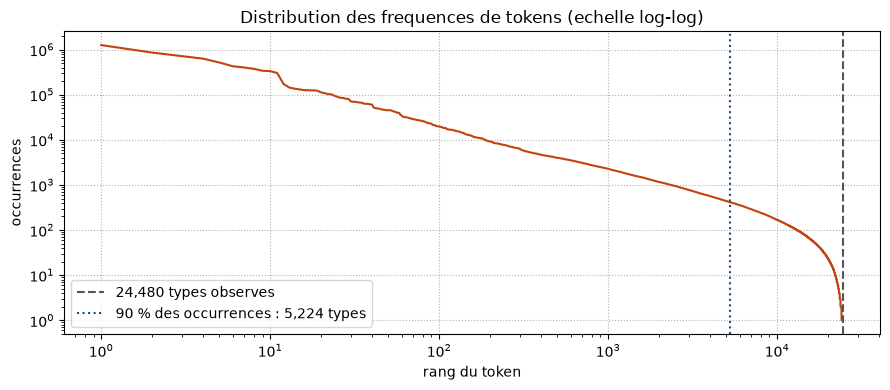

In [13]:
figure, axes = plt.subplots(figsize=(9.0, 4.0))

frequencies = [count for _, count in ordered]
axes.loglog(range(1, len(frequencies) + 1), frequencies, color=SCRATCH_COLOUR, linewidth=1.5)
axes.axvline(observed, color="#555555", linestyle="--", label=f"{observed:,} types observes")
axes.axvline(index_of[0.9], color=PRETRAINED_COLOUR, linestyle=":", label=f"90 % des occurrences : {index_of[0.9]:,} types")
axes.set_title("Distribution des frequences de tokens (echelle log-log)")
axes.set_xlabel("rang du token")
axes.set_ylabel("occurrences")
axes.legend()

figure.tight_layout()
plt.show()

La droite quasi parfaite sur une échelle log-log est une loi de Zipf. Le point qui compte est
**l'endroit où la courbe s'effondre** : au-delà du rang 22 154, les fréquences tombent sous dix
occurrences. Tout ce qui est à droite est une ligne d'embedding que ce corpus ne peut pas
apprendre.

## 7. Fragmentation en sous-mots

Le tokenizer `t5-small` est un SentencePiece : il ne produit jamais de token inconnu, il découpe
en morceaux. L'absence d'`<unk>` n'est donc pas une bonne nouvelle en soi, elle déplace le
problème. Le taux de fragmentation dit combien.

In [14]:
source_words = sum(len(example.source.split()) for example in splits["train"])
source_pieces = sum(len(identifiers_) for identifiers_ in encoded_sources)
target_words = sum(len(example.target.split()) for example in splits["train"])
target_pieces = sum(len(identifiers_) for identifiers_ in encoded_targets)

print(f"documents : {source_pieces / source_words:.3f} tokens par mot")
print(f"resumes   : {target_pieces / target_words:.3f} tokens par mot")
print()
print(f"un plafond de {cap_source} tokens vaut donc environ {cap_source / (source_pieces / source_words):.0f} mots")

documents : 1.423 tokens par mot
resumes   : 1.448 tokens par mot

un plafond de 512 tokens vaut donc environ 360 mots


**1,42 token par mot** est un taux sain pour de l'anglais journalistique : la majorité des mots
courants tiennent en un seul morceau, la fragmentation se concentre sur les noms propres. Le
plafond de 512 tokens correspond donc à environ **360 mots**, à comparer à la médiane de 634 mots
par article.

Le rapprochement de ces deux chiffres est le constat central : **le plafond tombe sous la
médiane**. Il ne rogne pas une queue de distribution, il coupe l'article médian avant sa moitié.
C'est ce qui distingue cette troncature de celle d'un corpus de dépêches courtes, où le même
plafond ne touchait qu'une minorité de documents.

## 8. Exemples extrêmes

Les deux bouts de la distribution ne sont pas des anomalies à retirer : ils disent ce que le
modèle doit encaisser dans le pire cas.

In [15]:
pairs = sorted(zip(source_lengths, splits["train"], strict=False), key=lambda item: item[0])

for label, (length, example) in (("Le plus court", pairs[0]), ("Le plus long", pairs[-1])):
    print(f"--- {label} : {length} tokens, {len(example.source.split())} mots ---")
    print("document :", example.source[:300].replace(chr(10), " "), "...")
    print("resume   :", example.target)
    print()

--- Le plus court : 69 tokens, 37 mots ---
document : World-renowned chef, author and Emmy winning television personality Anthony Bourdain visits Tangier, Morocco in the next episode of "Anthony Bourdain: Parts Unknown," airing Sunday, May 12, at 9 p.m. ET. Follow the show on Twitter and Facebook. ...
resume   : A tour of Morocco . 10 things you may not have known about Morocco .

--- Le plus long : 4449 tokens, 2150 mots ---
document : David Moyes' first home game as the new Manchester United manager will be against Jose Mourinho's Chelsea. Barclays Premier League champions United face a nightmare start to the 2013-14 season with trips to bitter rivals Liverpool and Manchester City in the opening five games. United begin at League ...
resume   : Premier League fixtures for 2013-14 season announced . Man United face Chelsea, Liverpool and Man City in opening five games . Play-off winners Crystal Palace start with London derby at home to Spurs .



Le document le plus long, 4 449 tokens, est un calendrier de championnat : une liste, pas un
article. Les trois rencontres que sa référence retient sont annoncées dans ses premières phrases,
et tout le reste est une énumération. C'est le type d'exemple pour lequel la troncature à 512
tokens ne dégrade rien, parce que rien d'exploitable n'était présent au-delà non plus.

Le plus court, 69 tokens, est une annonce d'émission de trois phrases. Sa référence promet
« 10 things you may not have known about Morocco », qui ne figure nulle part dans le document :
la référence de CNN/DailyMail est une puce de sommaire, pas toujours une phrase extraite. C'est
le cas défavorable, et aucune troncature ne l'explique.

Ces deux exemples sont conservés dans le corpus. Les retirer relèverait la moyenne pour avoir
écarté ce qui est difficile.

## 9. Budget d'entraînement

Dernière question, celle qui dimensionne la campagne : combien de tokens chaque proportion de
l'ablation représente-t-elle réellement, une fois la troncature appliquée ?

In [16]:
print(f"{'proportion':>12}{'exemples':>11}{'tokens source':>16}{'tokens cible':>15}")
print("-" * 54)
for percentage, examples in proportions.items():
    size = len(examples)
    source_budget = sum(min(length, cap_source) for length in source_lengths[:size])
    target_budget = sum(min(length, cap_target) for length in target_lengths[:size])
    print(f"{percentage:>11} %{size:>11,}{source_budget:>16,}{target_budget:>15,}")

  proportion   exemples   tokens source   tokens cible
------------------------------------------------------
         10 %      2,000         983,512        145,647
         50 %     10,000       4,936,681        732,684
        100 %     20,000       9,881,026      1,468,989


**Ce que cela veut dire pour l'ablation.** Le point à 10 % ne représente que 0,98 million de
tokens source, une fois la troncature appliquée. À titre de repère, `t5-small` a été pré-entraîné
sur de l'ordre de 34 milliards de tokens, soit environ **35 000 fois plus**. Le modèle initialisé
aléatoirement part donc de zéro avec quatre ordres de grandeur de moins de texte que ce dont
dispose déjà la baseline avant même de commencer.

Ce chiffre, mesuré ici, est le meilleur repère pour lire la courbe du rapport : la comparaison
n'oppose pas deux modèles à données égales, et multiplier par dix un corpus de 20 000 exemples ne
change pas l'ordre de grandeur.

## Ce que l'EDA a fixé

| Constat | Décision |
| --- | --- |
| Médiane des articles à 899 tokens, coût quadratique de l'attention | `max_source_tokens = 512`, 85,3 % d'articles coupés, 50 % du texte gardé |
| p95 des résumés à 130 tokens, 59,7 % coupés à 64 | `max_target_tokens = 128`, 5,26 % de cibles coupées, `max_new_tokens` aligné |
| 76,3 % du vocabulaire observé, 50 % des occurrences dans 92 types | 6,5 % des paramètres ne reçoivent jamais de gradient |
| 88 % d'unigrammes et 50 % de bigrammes du résumé déjà dans l'article | tâche extractive, ROUGE-L non comparable au ROUGE-Lsum publié |
| 0,98 million de tokens à 10 % du corpus | l'écart avec le pré-entraîné n'est pas comblable par les données |
| Aucune fuite, sous-ensembles emboîtés | l'ablation mesure la taille, pas la composition |